# Notebook 2: EDA and Visualization

This notebook covers comprehensive Exploratory Data Analysis (EDA) with detailed visualizations for the NYC Taxi Trip Duration dataset.

**Objectives:**
1. Analyze the target variable distribution
2. Perform temporal analysis
3. Conduct geospatial analysis
4. Examine feature relationships
5. Analyze categorical features
6. Create comprehensive EDA report

## 1. Setup and Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src to path
sys.path.append('../src')

# Import utilities
from utils.visualization import *
from config import *

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(RANDOM_STATE)

print("Setup complete!")

Setup complete!


## 2. Load Dataset

In [14]:
# Load the dataset
processed_dir = Path('../data/processed')
if (processed_dir / 'initial_dataset.csv').exists():
    df = pd.read_csv(processed_dir / 'initial_dataset.csv')
    print(f"Loaded dataset from {processed_dir / 'initial_dataset.csv'}")
else:
    # Load from raw data if processed doesn't exist
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded dataset from {DATA_PATH}")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loaded dataset from ../data/processed/initial_dataset.csv
Dataset shape: (1458644, 11)
Columns: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']


## 3. Target Variable Analysis

Target Variable: trip_duration
Summary Statistics:
count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64


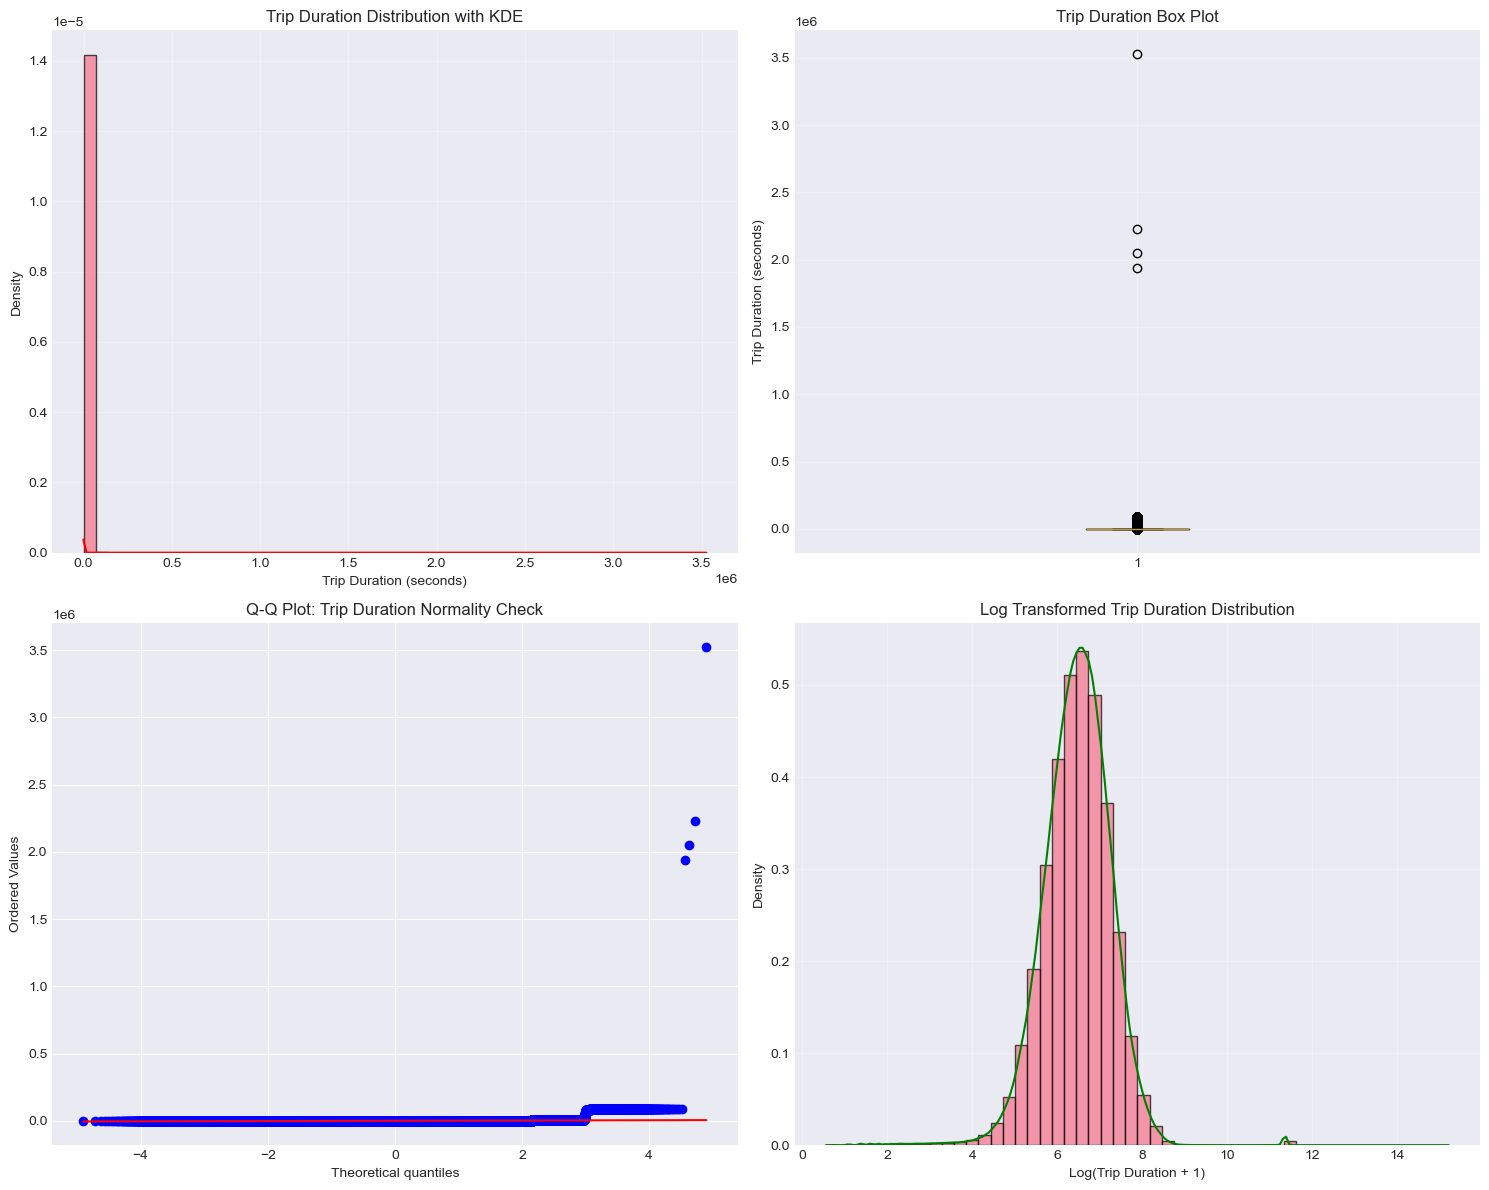

In [15]:
print("Target Variable: trip_duration")
print("="*50)

# Basic statistics for target variable
target_stats = df['trip_duration'].describe()
print("Summary Statistics:")
print(target_stats)

# Distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram with KDE
axes[0, 0].hist(df['trip_duration'], bins=50, alpha=0.7, edgecolor='black', density=True)
sns.kdeplot(df['trip_duration'], ax=axes[0, 0], color='red')
axes[0, 0].set_xlabel('Trip Duration (seconds)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Trip Duration Distribution with KDE')
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(df['trip_duration'])
axes[0, 1].set_ylabel('Trip Duration (seconds)')
axes[0, 1].set_title('Trip Duration Box Plot')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot for normality check
from scipy import stats
stats.probplot(df['trip_duration'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Trip Duration Normality Check')

# Log transformation analysis
log_trip_duration = np.log1p(df['trip_duration'])
axes[1, 1].hist(log_trip_duration, bins=50, alpha=0.7, edgecolor='black', density=True)
sns.kdeplot(log_trip_duration, ax=axes[1, 1], color='green')
axes[1, 1].set_xlabel('Log(Trip Duration + 1)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Log Transformed Trip Duration Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/eda/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# Outlier detection
Q1 = df['trip_duration'].quantile(0.25)
Q3 = df['trip_duration'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['trip_duration'] < lower_bound) | (df['trip_duration'] > upper_bound)]
print(f"Outliers detected: {len(outliers)}")
print(f"Percentage of outliers: {(len(outliers) / len(df)) * 100:.2f}%")
print(f"Outlier range: {lower_bound:.2f} to {upper_bound:.2f} seconds")
print(f"Min trip duration: {df['trip_duration'].min():.2f} seconds")
print(f"Max trip duration: {df['trip_duration'].max():.2f} seconds")

Outliers detected: 74220
Percentage of outliers: 5.09%
Outlier range: -620.00 to 2092.00 seconds
Min trip duration: 1.00 seconds
Max trip duration: 3526282.00 seconds


## 4. Temporal Analysis

In [17]:
# Convert datetime columns
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Extract temporal features
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year

print("Temporal Features Extracted:")
print(f"Hours: {df['hour'].min()} - {df['hour'].max()}")
print(f"Days of week: {df['day_of_week'].min()} - {df['day_of_week'].max()}")
print(f"Months: {df['month'].min()} - {df['month'].max()}")

Temporal Features Extracted:
Hours: 0 - 23
Days of week: 0 - 6
Months: 1 - 6


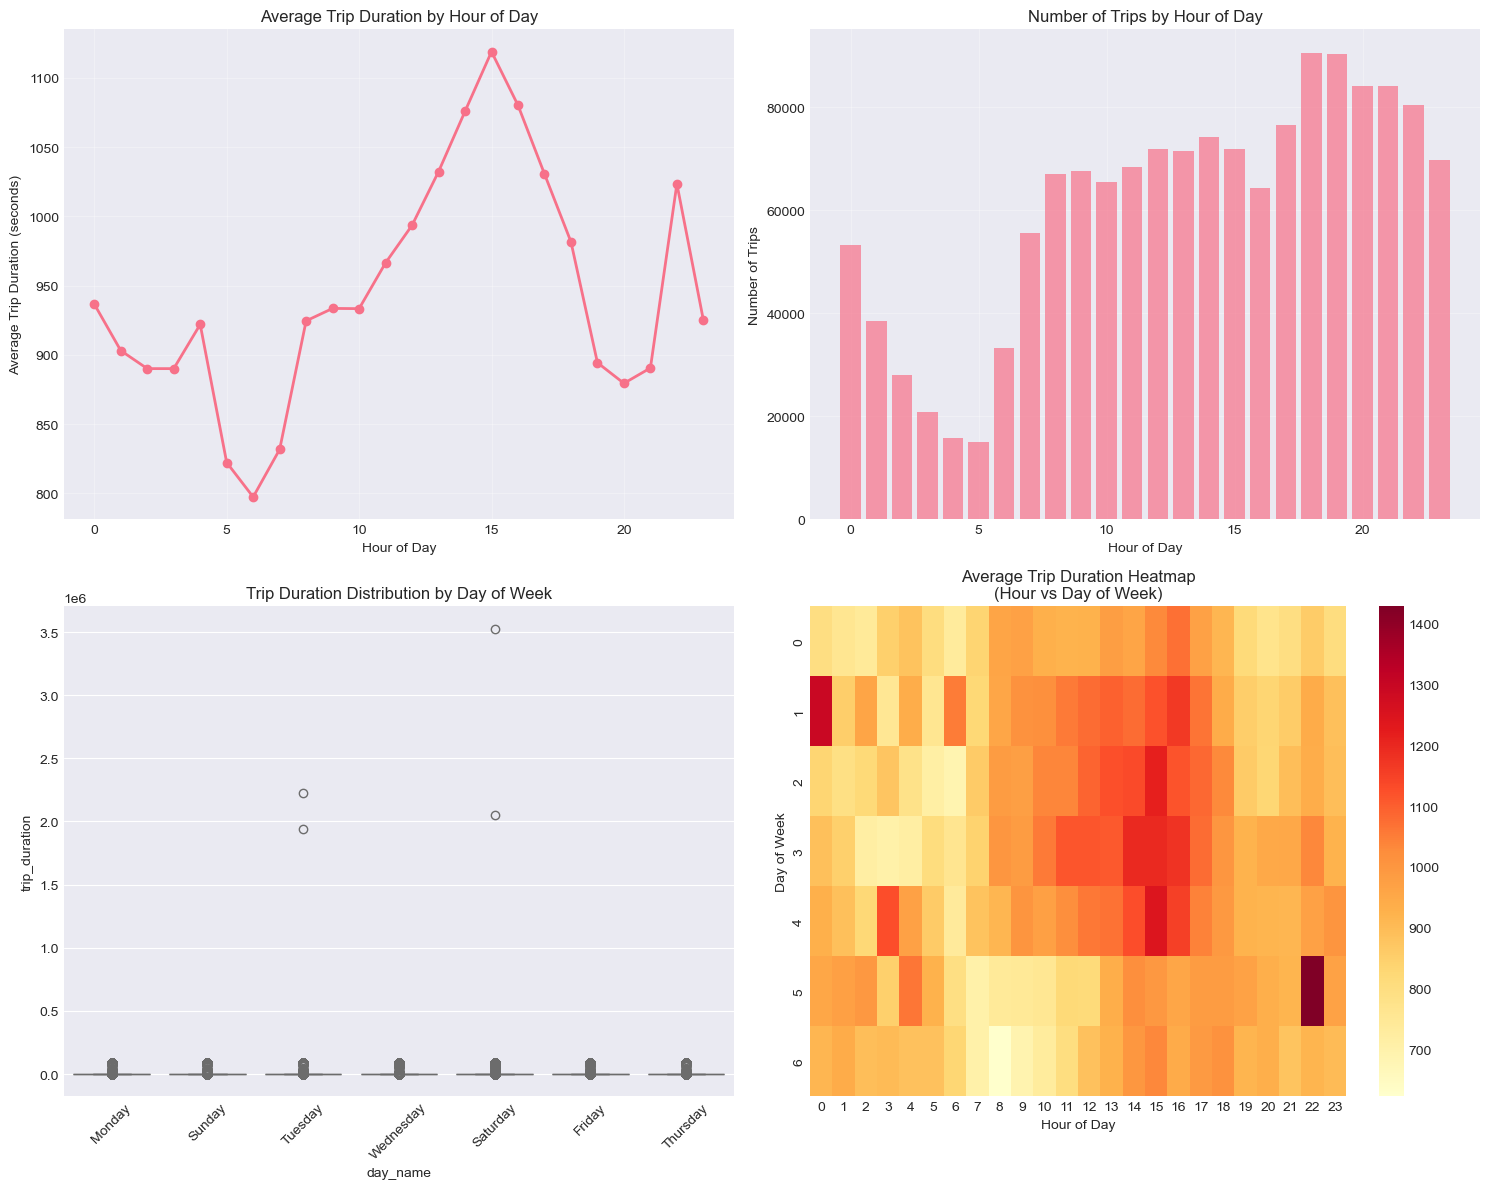

In [18]:
# Trip duration by hour of day
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Line plot: Average trip duration by hour
hourly_avg = df.groupby('hour')['trip_duration'].mean()
axes[0, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Average Trip Duration (seconds)')
axes[0, 0].set_title('Average Trip Duration by Hour of Day')
axes[0, 0].grid(True, alpha=0.3)

# Bar plot: Trip count by hour
hourly_count = df['hour'].value_counts().sort_index()
axes[0, 1].bar(hourly_count.index, hourly_count.values, alpha=0.7)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Number of Trips')
axes[0, 1].set_title('Number of Trips by Hour of Day')
axes[0, 1].grid(True, alpha=0.3)

# Box plot: Trip duration by day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_name'] = df['day_of_week'].map({i: name for i, name in enumerate(day_names)})
sns.boxplot(data=df, x='day_name', y='trip_duration', ax=axes[1, 0])
axes[1, 0].set_title('Trip Duration Distribution by Day of Week')
axes[1, 0].tick_params(axis='x', rotation=45)

# Heatmap: Hour vs Day of Week
pivot_table = df.groupby(['day_of_week', 'hour'])['trip_duration'].mean().unstack()
sns.heatmap(pivot_table, cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Average Trip Duration Heatmap\n(Hour vs Day of Week)')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('../plots/eda/temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Geospatial Analysis

Geospatial Analysis:


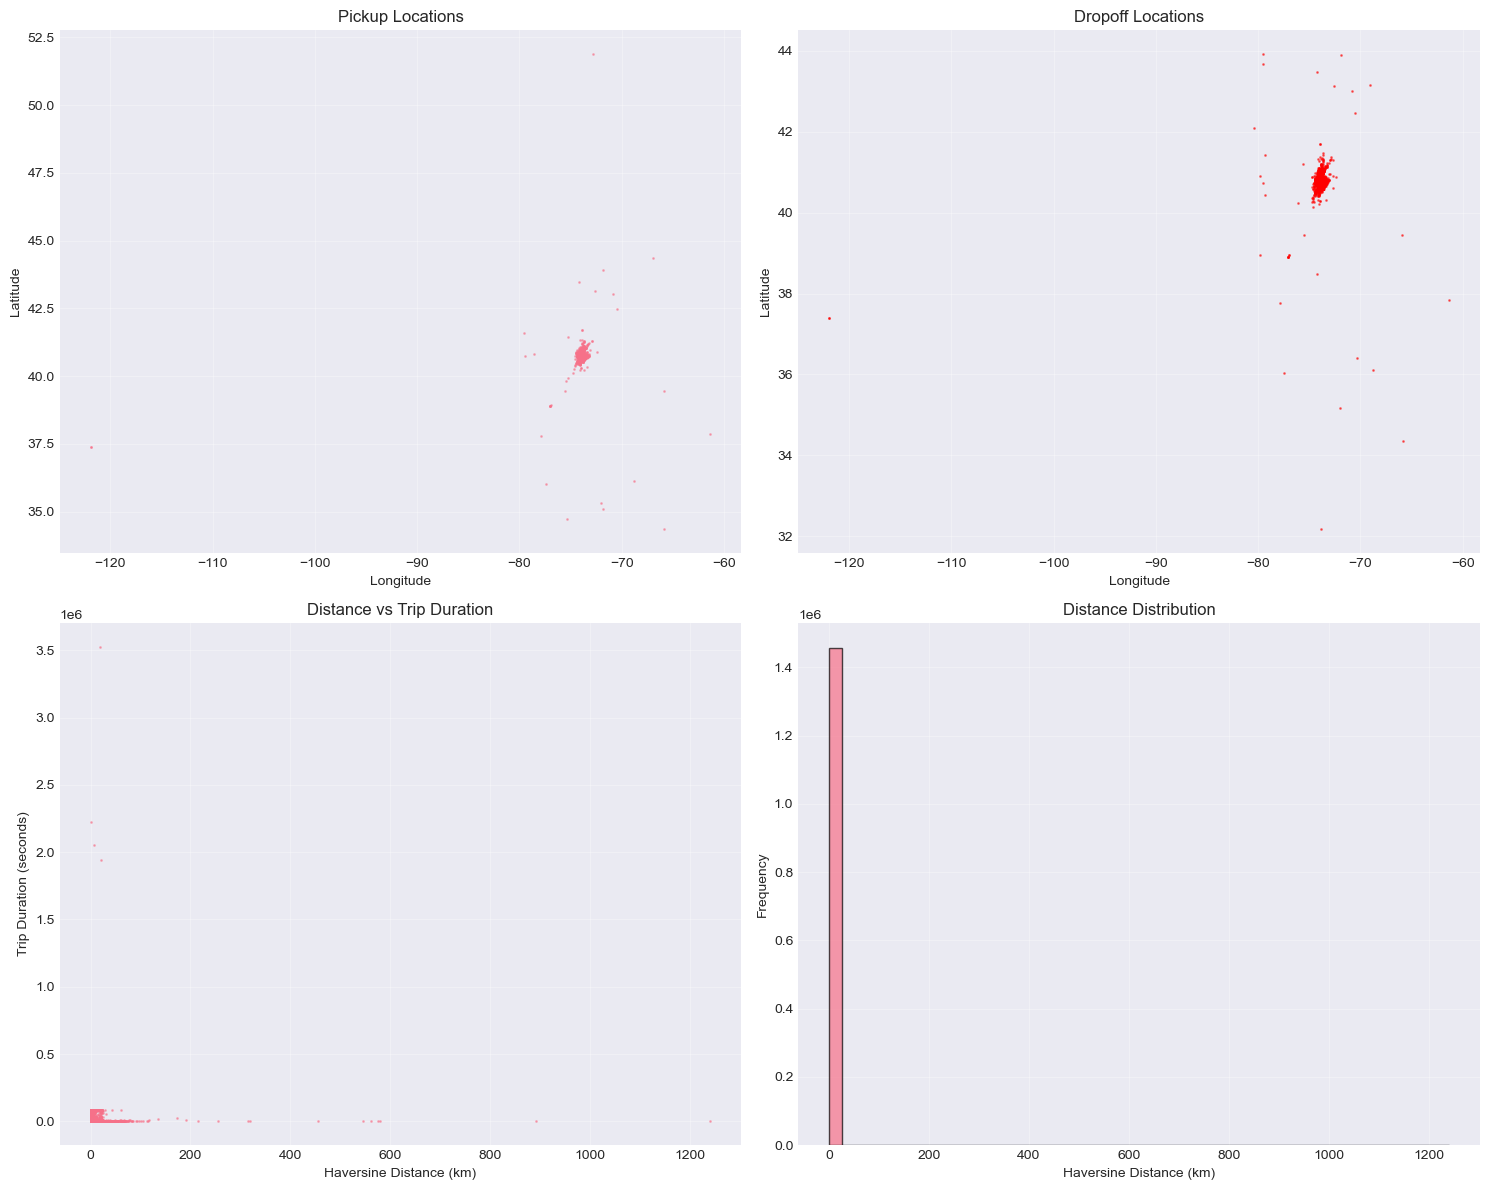

Average distance: 3.44 km
Median distance: 2.09 km
Max distance: 1240.91 km


In [19]:
# Import geospatial utilities
from utils.feature_engineering import haversine_distance

print("Geospatial Analysis:")
print("="*50)

# Pickup location scatter plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Pickup locations
axes[0, 0].scatter(df['pickup_longitude'], df['pickup_latitude'], alpha=0.5, s=1)
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
axes[0, 0].set_title('Pickup Locations')
axes[0, 0].grid(True, alpha=0.3)

# Dropoff locations
axes[0, 1].scatter(df['dropoff_longitude'], df['dropoff_latitude'], alpha=0.5, s=1, color='red')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')
axes[0, 1].set_title('Dropoff Locations')
axes[0, 1].grid(True, alpha=0.3)

# Calculate distances
df['haversine_distance'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Distance vs Duration scatter plot
axes[1, 0].scatter(df['haversine_distance'], df['trip_duration'], alpha=0.5, s=1)
axes[1, 0].set_xlabel('Haversine Distance (km)')
axes[1, 0].set_ylabel('Trip Duration (seconds)')
axes[1, 0].set_title('Distance vs Trip Duration')
axes[1, 0].grid(True, alpha=0.3)

# Distance distribution
axes[1, 1].hist(df['haversine_distance'], bins=50, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Haversine Distance (km)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distance Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/eda/geospatial_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average distance: {df['haversine_distance'].mean():.2f} km")
print(f"Median distance: {df['haversine_distance'].median():.2f} km")
print(f"Max distance: {df['haversine_distance'].max():.2f} km")

## 6. Feature Relationships

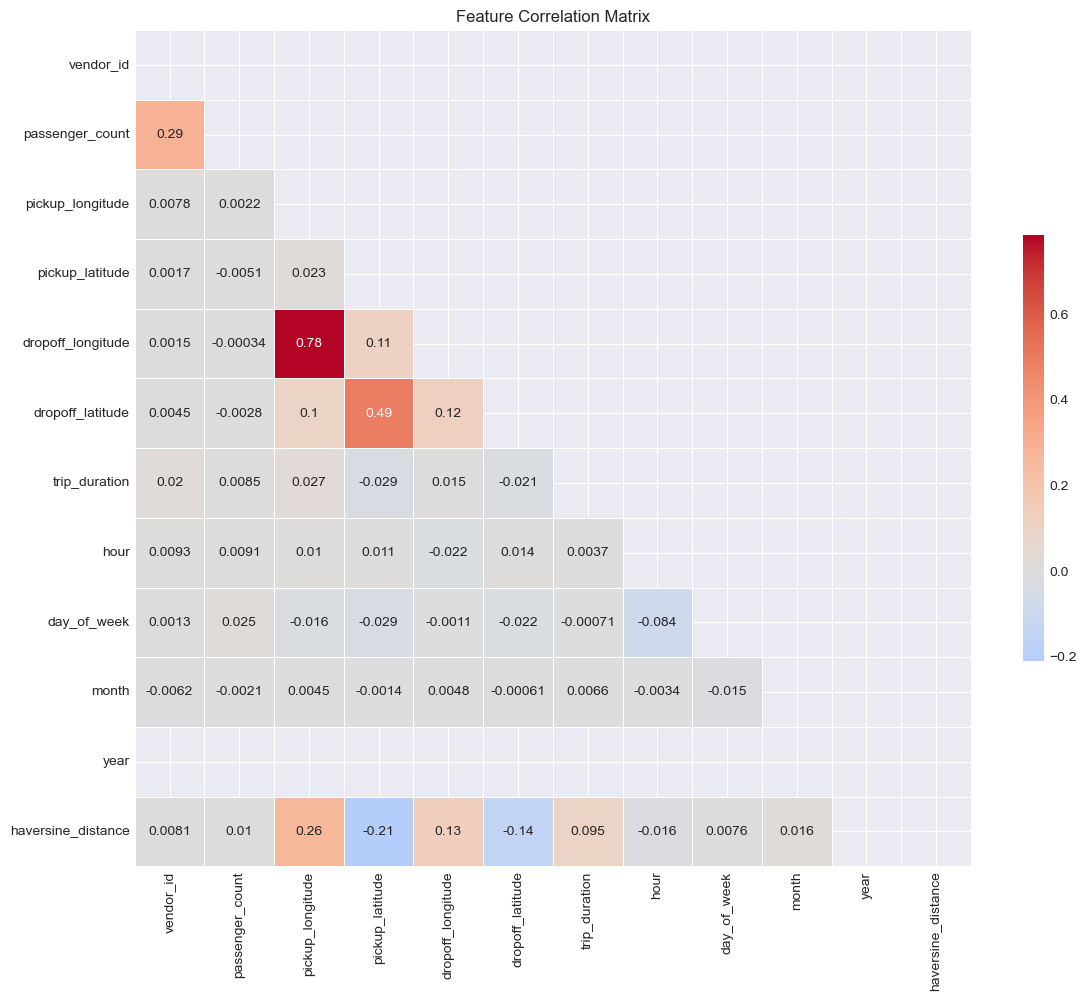

<Figure size 1200x1200 with 0 Axes>

In [ ]:
# Correlation matrix
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../plots/eda/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Pairplot for selected features
selected_features = ['trip_duration', 'haversine_distance', 'passenger_count', 'hour']
if all(col in df.columns for col in selected_features):
    plt.figure(figsize=(12, 12))
    pd.plotting.scatter_matrix(df[selected_features], figsize=(12, 12), alpha=0.2)
    plt.suptitle('Pairplot of Selected Features')
    plt.tight_layout()
    plt.savefig('../plots/eda/pairplot_selected_features.png', dpi=300, bbox_inches='tight')
    plt.show()

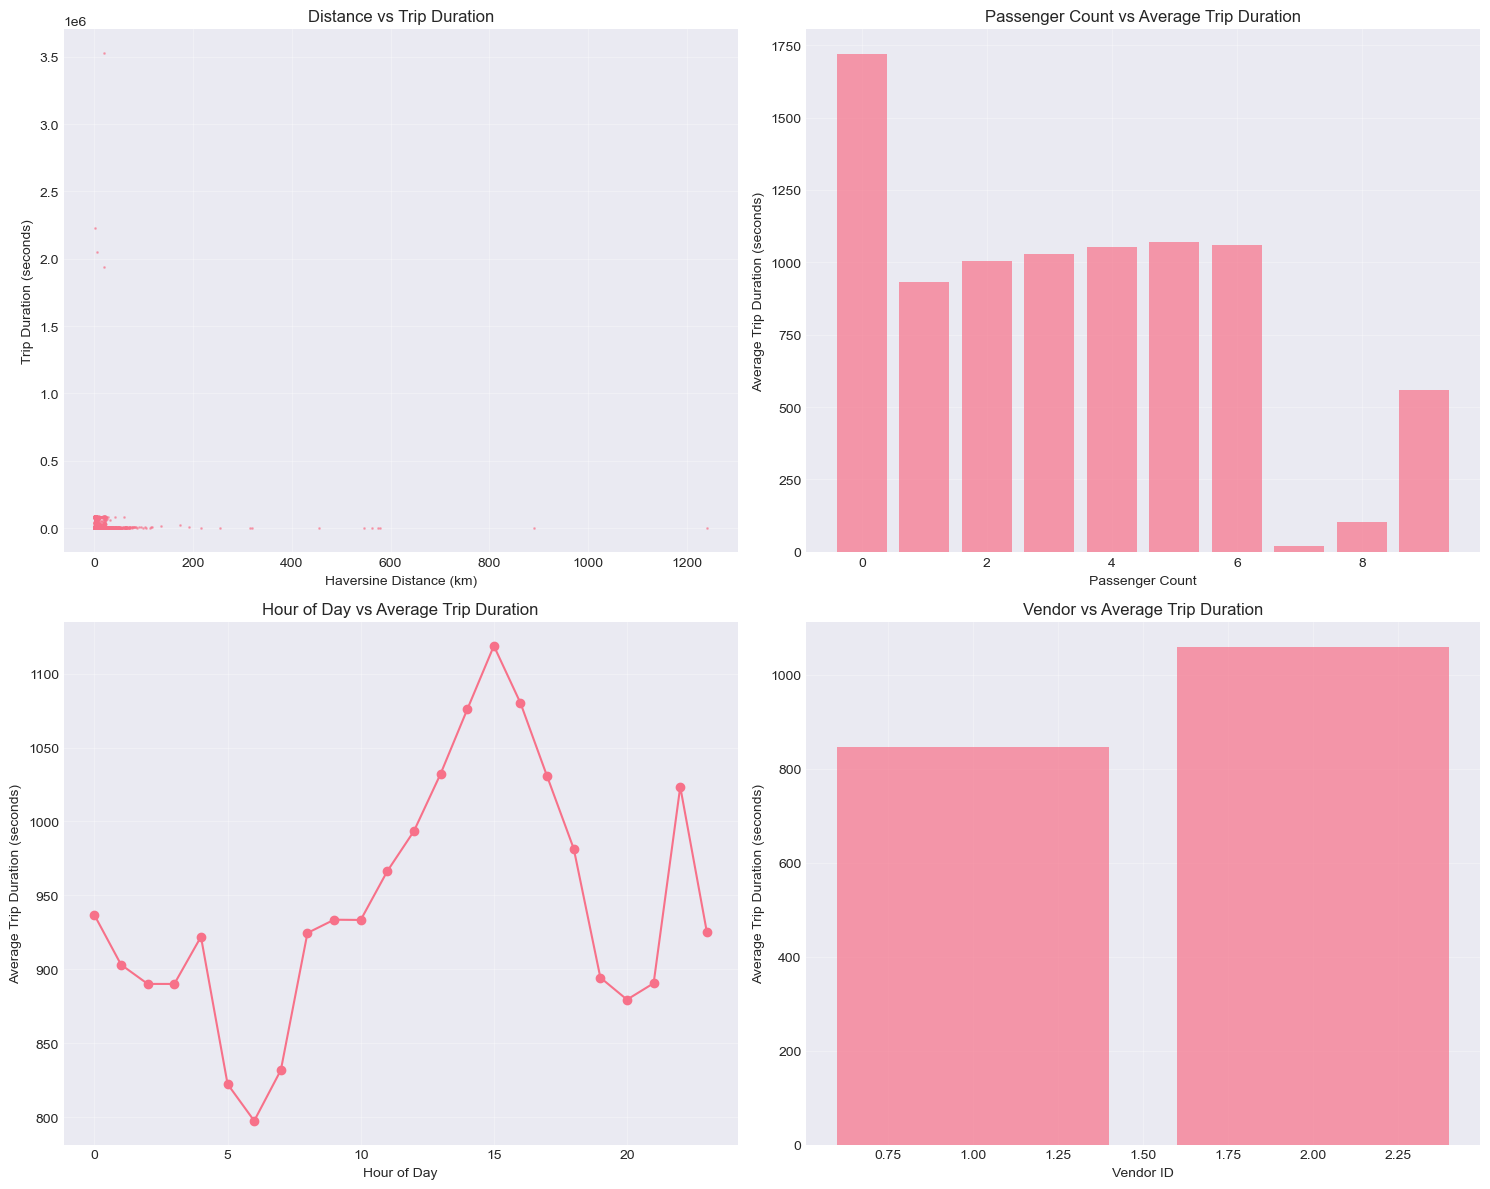

In [ ]:
# Scatter plots: key features vs target
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Distance vs Duration
axes[0, 0].scatter(df['haversine_distance'], df['trip_duration'], alpha=0.5, s=1)
axes[0, 0].set_xlabel('Haversine Distance (km)')
axes[0, 0].set_ylabel('Trip Duration (seconds)')
axes[0, 0].set_title('Distance vs Trip Duration')
axes[0, 0].grid(True, alpha=0.3)

# Passenger count vs Duration
passenger_avg = df.groupby('passenger_count')['trip_duration'].mean()
axes[0, 1].bar(passenger_avg.index, passenger_avg.values, alpha=0.7)
axes[0, 1].set_xlabel('Passenger Count')
axes[0, 1].set_ylabel('Average Trip Duration (seconds)')
axes[0, 1].set_title('Passenger Count vs Average Trip Duration')
axes[0, 1].grid(True, alpha=0.3)

# Hour vs Duration
hourly_avg = df.groupby('hour')['trip_duration'].mean()
axes[1, 0].plot(hourly_avg.index, hourly_avg.values, marker='o')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Average Trip Duration (seconds)')
axes[1, 0].set_title('Hour of Day vs Average Trip Duration')
axes[1, 0].grid(True, alpha=0.3)

# Vendor vs Duration
if 'vendor_id' in df.columns:
    vendor_avg = df.groupby('vendor_id')['trip_duration'].mean()
    axes[1, 1].bar(vendor_avg.index, vendor_avg.values, alpha=0.7)
    axes[1, 1].set_xlabel('Vendor ID')
    axes[1, 1].set_ylabel('Average Trip Duration (seconds)')
    axes[1, 1].set_title('Vendor vs Average Trip Duration')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Vendor ID not available', ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Vendor Analysis')

plt.tight_layout()
plt.savefig('../plots/eda/feature_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Categorical Features Analysis

/var/folders/c2/074r245x2bsbymf50gjtfrnr0000gn/T/ipykernel_20341/2667614081.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Categorical columns: ['id', 'store_and_fwd_flag', 'day_name']


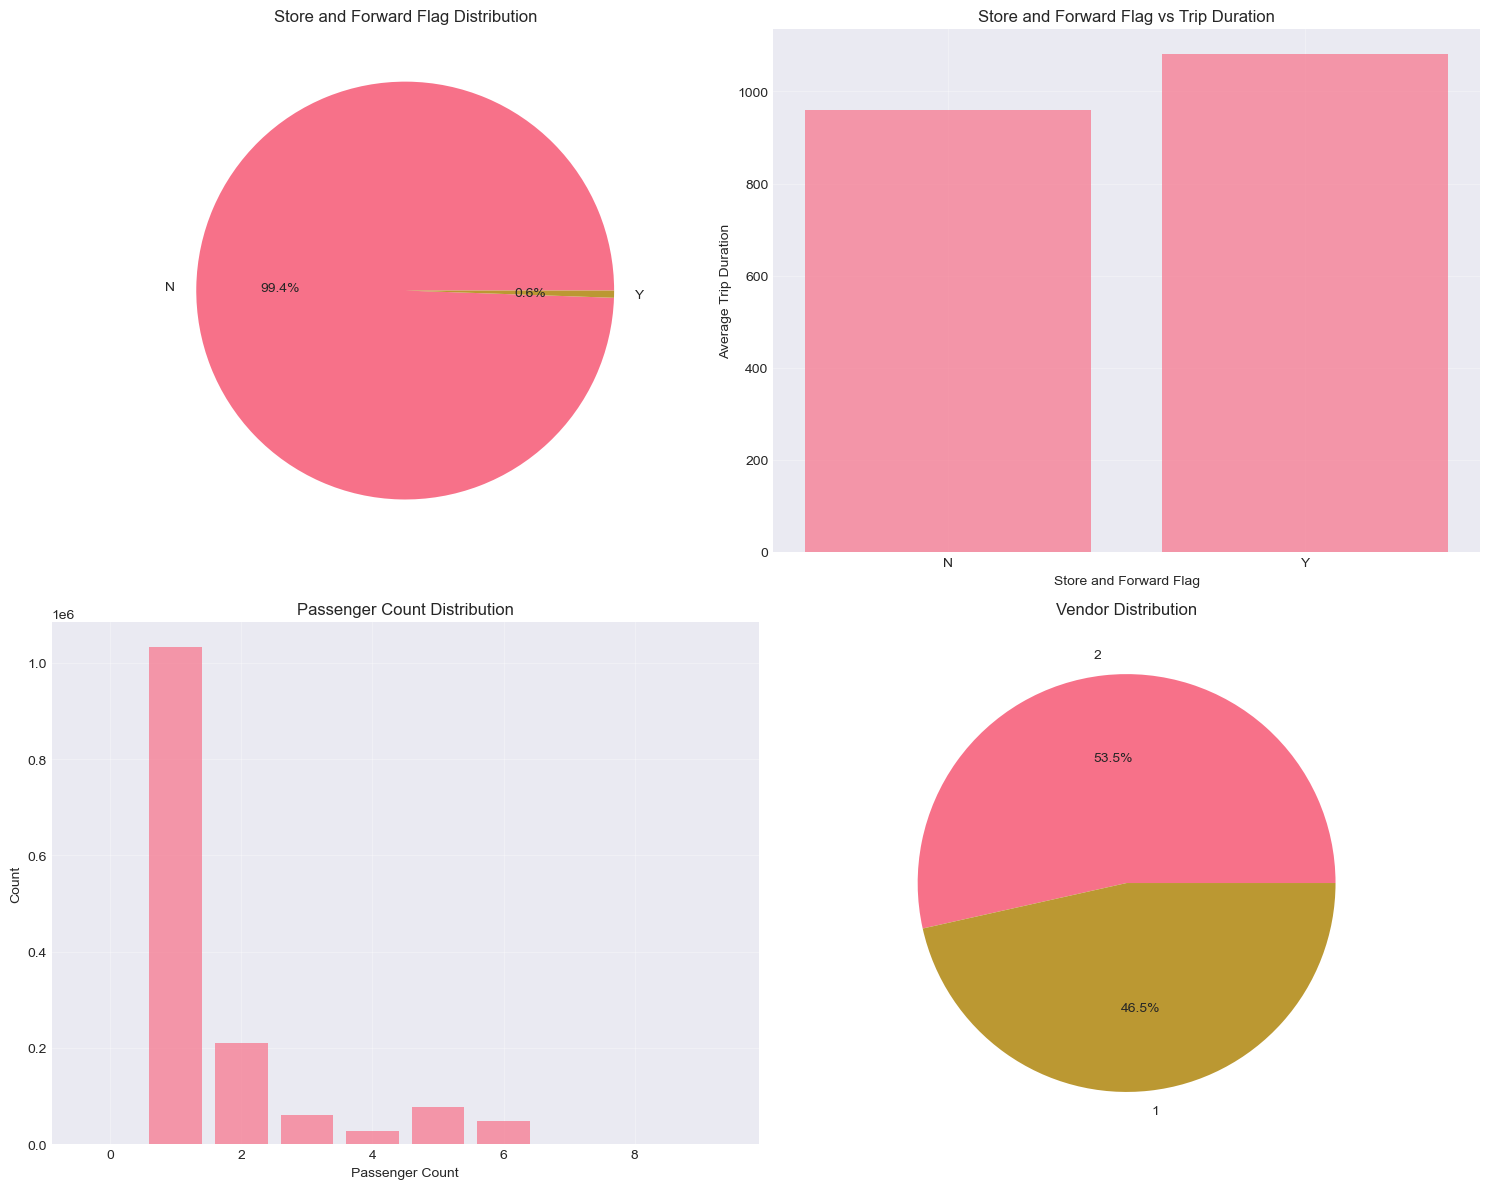

In [ ]:
# Categorical features
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(categorical_cols)}")

if len(categorical_cols) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Store and forward flag
    if 'store_and_fwd_flag' in df.columns:
        flag_counts = df['store_and_fwd_flag'].value_counts()
        axes[0, 0].pie(flag_counts.values, labels=flag_counts.index, autopct='%1.1f%%')
        axes[0, 0].set_title('Store and Forward Flag Distribution')
        
        # Flag vs Duration
        flag_avg = df.groupby('store_and_fwd_flag')['trip_duration'].mean()
        axes[0, 1].bar(flag_avg.index, flag_avg.values, alpha=0.7)
        axes[0, 1].set_xlabel('Store and Forward Flag')
        axes[0, 1].set_ylabel('Average Trip Duration')
        axes[0, 1].set_title('Store and Forward Flag vs Trip Duration')
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 0].text(0.5, 0.5, 'No categorical data available', ha='center', va='center', transform=axes[0, 0].transAxes)
        axes[0, 1].text(0.5, 0.5, 'No categorical data available', ha='center', va='center', transform=axes[0, 1].transAxes)
    
    # Passenger count distribution
    if 'passenger_count' in df.columns:
        passenger_counts = df['passenger_count'].value_counts().sort_index()
        axes[1, 0].bar(passenger_counts.index, passenger_counts.values, alpha=0.7)
        axes[1, 0].set_xlabel('Passenger Count')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].set_title('Passenger Count Distribution')
        axes[1, 0].grid(True, alpha=0.3)
    
    # Vendor distribution
    if 'vendor_id' in df.columns:
        vendor_counts = df['vendor_id'].value_counts()
        axes[1, 1].pie(vendor_counts.values, labels=vendor_counts.index, autopct='%1.1f%%')
        axes[1, 1].set_title('Vendor Distribution')
    
    plt.tight_layout()
    plt.savefig('../plots/eda/categorical_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No categorical columns found in the dataset.")

## 8. Statistical Summary and Insights

In [ ]:
print("\n" + "="*60)
print("EDA SUMMARY AND KEY FINDINGS")
print("="*60)

print("\n1. TARGET VARIABLE (trip_duration):")
print(f"   - Range: {df['trip_duration'].min():.2f} to {df['trip_duration'].max():.2f} seconds")
print(f"   - Mean: {df['trip_duration'].mean():.2f} seconds")
print(f"   - Median: {df['trip_duration'].median():.2f} seconds")
print(f"   - Standard Deviation: {df['trip_duration'].std():.2f}")
print(f"   - Outliers: {len(outliers)} ({(len(outliers)/len(df))*100:.2f}%)")

print("\n2. TEMPORAL PATTERNS:")
print(f"   - Data spans {df['year'].nunique()} years")
print(f"   - Data spans {df['month'].nunique()} months")
print(f"   - Peak hours: {hourly_avg.idxmax()} (avg duration: {hourly_avg.max():.2f}s)")
print(f"   - Lowest hours: {hourly_avg.idxmin()} (avg duration: {hourly_avg.min():.2f}s)")

print("\n3. GEOGRAPHICAL INSIGHTS:")
print(f"   - Average trip distance: {df['haversine_distance'].mean():.2f} km")
print(f"   - Median trip distance: {df['haversine_distance'].median():.2f} km")
print(f"   - Longest trip: {df['haversine_distance'].max():.2f} km")

print("\n4. FEATURE RELATIONSHIPS:")
correlation_with_target = correlation_matrix['trip_duration'].sort_values(ascending=False)
print("   Top 5 features correlated with trip_duration:")
for i, (feature, corr) in enumerate(correlation_with_target.head(6).items()):
    if feature != 'trip_duration':
        print(f"   {i+1}. {feature}: {corr:.3f}")

print("\n5. DATA QUALITY ISSUES IDENTIFIED:")
print("   - Missing values: Check individual columns")
print("   - Outliers: Present in trip_duration")
print("   - Skewed distributions: Trip duration is right-skewed")
print("   - Potential data leakage: Check for features that shouldn't be available")


EDA SUMMARY AND KEY FINDINGS

1. TARGET VARIABLE (trip_duration):
   - Range: 1.00 to 3526282.00 seconds
   - Mean: 959.49 seconds
   - Median: 662.00 seconds
   - Standard Deviation: 5237.43
   - Outliers: 74220 (5.09%)

2. TEMPORAL PATTERNS:
   - Data spans 1 years
   - Data spans 6 months
   - Peak hours: 15 (avg duration: 1118.83s)
   - Lowest hours: 6 (avg duration: 797.43s)

3. GEOGRAPHICAL INSIGHTS:
   - Average trip distance: 3.44 km
   - Median trip distance: 2.09 km
   - Longest trip: 1240.91 km

4. FEATURE RELATIONSHIPS:
   Top 5 features correlated with trip_duration:
   2. haversine_distance: 0.095
   3. pickup_longitude: 0.027
   4. vendor_id: 0.020
   5. dropoff_longitude: 0.015
   6. passenger_count: 0.008

5. DATA QUALITY ISSUES IDENTIFIED:
   - Missing values: Check individual columns
   - Outliers: Present in trip_duration
   - Skewed distributions: Trip duration is right-skewed
   - Potential data leakage: Check for features that shouldn't be available


## 9. Save EDA Results

In [ ]:
# Create EDA results directory
eda_dir = Path('../data/results')
eda_dir.mkdir(parents=True, exist_ok=True)

# Save correlation matrix
correlation_matrix.to_csv(eda_dir / 'correlation_matrix.csv')

# Save feature statistics
feature_stats = df.describe()
feature_stats.to_csv(eda_dir / 'feature_statistics.csv')

# Save target variable analysis
target_analysis = pd.DataFrame({
    'statistic': ['min', 'max', 'mean', 'median', 'std', 'skewness', 'kurtosis'],
    'value': [
        df['trip_duration'].min(),
        df['trip_duration'].max(),
        df['trip_duration'].mean(),
        df['trip_duration'].median(),
        df['trip_duration'].std(),
        df['trip_duration'].skew(),
        df['trip_duration'].kurtosis()
    ]
})
target_analysis.to_csv(eda_dir / 'target_variable_analysis.csv', index=False)

print(f"EDA results saved to: {eda_dir}")
print("Files created:")
print("- correlation_matrix.csv")
print("- feature_statistics.csv")
print("- target_variable_analysis.csv")
print("\nPlots saved to: ../plots/eda/")
print("- target_distribution.png")
print("- temporal_analysis.png")
print("- geospatial_analysis.png")
print("- correlation_heatmap.png")
print("- pairplot_selected_features.png")
print("- feature_relationships.png")
print("- categorical_analysis.png")

EDA results saved to: ../data/results
Files created:
- correlation_matrix.csv
- feature_statistics.csv
- target_variable_analysis.csv

Plots saved to: ../plots/eda/
- target_distribution.png
- temporal_analysis.png
- geospatial_analysis.png
- correlation_heatmap.png
- pairplot_selected_features.png
- feature_relationships.png
- categorical_analysis.png


## 10. EDA Conclusions and Next Steps

### Key EDA Findings:

1. **Target Variable Characteristics**:
   - Trip duration shows right-skewed distribution
   - Contains outliers that may need handling
   - Log transformation may be beneficial

2. **Temporal Patterns**:
   - Clear hourly patterns in trip duration
   - Weekend vs weekday differences
   - Rush hour effects visible

3. **Geographical Insights**:
   - Strong correlation between distance and duration
   - Geographic clustering of pickup/dropoff locations
   - Potential for location-based features

4. **Feature Relationships**:
   - Distance is the strongest predictor
   - Time-based features show moderate correlations
   - Passenger count has limited impact

### Recommendations for Next Steps:

1. **Feature Engineering**:
   - Create distance-based features
   - Extract more temporal features
   - Add location-based features

2. **Data Preprocessing**:
   - Handle outliers in trip_duration
   - Consider log transformation
   - Address missing values

3. **Modeling Strategy**:
   - Start with distance as primary feature
   - Add temporal features incrementally
   - Consider ensemble methods for non-linear relationships